In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd


from Autoencoders import ConformalAutoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from metrics import evaluate_conformality

from torchvision.datasets import MNIST
from torchvision import transforms


random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
class Encoder(nn.Module):
    def __init__(self, in_channels, latent_dim):
        super(Encoder, self).__init__()
        #input dim = 1, 32, 32
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 8, 3, stride=2, padding=1),  # (8, 16, 16)
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),  # (16, 8, 8)
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # (32, 4, 4)
            nn.ReLU(True),
        )

        self.fc = nn.Sequential(
            nn.Linear(32 * 4 * 4, 64),  # Flatten to (64,)
            nn.ReLU(True),
            nn.Linear(64, latent_dim)  # Output latent dimension
        )
    
    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x

class Decoder(nn.Module):
    def __init__(self, out_channels, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),  # Input latent dimension
            nn.ReLU(True),
            nn.Linear(64, 32 * 4 * 4),  # Output size to reshape
            nn.ReLU(True),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),  # (16, 6, 6)
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),  # (8, 12, 12)
            nn.ReLU(True),
            nn.ConvTranspose2d(8, out_channels, 3, stride=2, padding=1, output_padding=1),  # (out_channels, 28, 28)
            nn.Sigmoid()  # For pixel values between 0 and 1
        )
    
    def forward(self, z):
        z = self.fc(z)
        z = torch.unflatten(z, 1, (32, 4, 4))  # Reshape to (32, 4, 4)
        z = self.deconv(z)
        return z

In [3]:
mnist = MNIST(root='data', train=True, download=True, transform=None)
data, labels = mnist.data, mnist.targets
data = data[labels == 3][:3000]
labels = labels[labels == 3]
data = torch.tensor(data, dtype=torch.float32).to(device)
data = transforms.Resize((32, 32))(data)  # Resize to 32x32
data = data / 255.0  # Normalize the images to [0, 1]
data = data.view(data.size(0), 1, 32, 32)  # Add channel dimension
mnist_val = MNIST(root='data', train=False, download=True, transform=None)
val_data, val_labels = mnist_val.data, mnist_val.targets
val_data = val_data[val_labels == 3][:1000]
val_labels = val_labels[val_labels == 3]
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)
val_data = transforms.Resize((32, 32))(val_data)  # Resize to 32x32
val_data = val_data / 255.0  # Normalize the images to [0, 1]
val_data = val_data.view(val_data.size(0), 1, 32, 32)  # Add channel dimension

/tmp/ipykernel_109299/315428273.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data, dtype=torch.float32).to(device)
/tmp/ipykernel_109299/315428273.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_data = torch.tensor(val_data, dtype=torch.float32).to(device)


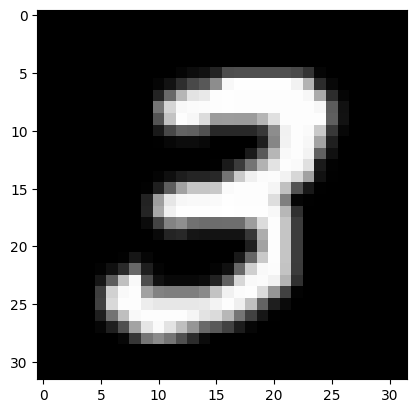

In [4]:
plt.imshow(data[0].view(32, 32).cpu().numpy(), cmap='gray')
plt.show()

In [5]:
# define model parameters
latent_dim = 32
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 256

in_channels = 1  # For grayscale images


train_dataloader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)

dir_path = "models/conformal_autoencoder_cosine_comp_mnist"

In [6]:
lambda_isos = np.logspace(-4, 3, 9)
lambda_isos = np.concat([np.zeros(1), lambda_isos])

In [7]:
import os

def modelpath(dir_path, lambda_iso, index):
    os.makedirs(dir_path, exist_ok=True)
    return f"{dir_path}/lambda_{lambda_iso:.3f}_model_{index+1}.pth"

In [8]:
from metrics import conformality_cosine2_loss

In [9]:
num_epochs = 1000
# train same model multiple times to average results
num_models = 3

recon_errors = []
regularization_errors = []


for i, lambda_iso in enumerate(lambda_isos):
    recon_error = 0
    regularization = 0
    for j in range(num_models):
        print(f"Training model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f}")

        encoder = Encoder(in_channels=in_channels, latent_dim=latent_dim).to(device)
        decoder = Decoder(latent_dim=latent_dim, out_channels=in_channels).to(device)
        model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)
        model.conformality_loss = conformality_cosine2_loss

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.8)

        # Train the model
        model.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=num_epochs,
                          optimizer=optimizer, scheduler=scheduler, verbose=True)

        # Save the model and optimizer state
        model_path = modelpath(dir_path, lambda_iso, j)
        torch.save(model.state_dict(), model_path)
        print(f"Model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f} trained and saved.")

        # evaluation
        model.eval()
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)
        
        recon_error += nn.MSELoss()(reconstruction, val_data).item()

        regularization += model.conformality_loss(model.decoder, encoded_data).item()
    
    recon_errors.append(recon_error/ num_models)
    regularization_errors.append(regularization/num_models)
    

Training model 1/3 with lambda_iso=0.000
Epoch [100/1000], Loss: 0.01271858, Reconstruction Loss: 0.01271858, Conformal Loss: 0.09247644
Epoch [100/1000], Validation Loss: 0.01282363, Reconstruction Loss: 0.01282363, Conformal Loss: 0.09802074
Epoch [200/1000], Loss: 0.00704770, Reconstruction Loss: 0.00704770, Conformal Loss: 0.06617338
Epoch [200/1000], Validation Loss: 0.00757729, Reconstruction Loss: 0.00757729, Conformal Loss: 0.06601344
Epoch [300/1000], Loss: 0.00580246, Reconstruction Loss: 0.00580246, Conformal Loss: 0.06241728
Epoch [300/1000], Validation Loss: 0.00653526, Reconstruction Loss: 0.00653526, Conformal Loss: 0.06103843
Epoch [400/1000], Loss: 0.00521302, Reconstruction Loss: 0.00521302, Conformal Loss: 0.05892190
Epoch [400/1000], Validation Loss: 0.00605776, Reconstruction Loss: 0.00605776, Conformal Loss: 0.06367526
Epoch [500/1000], Loss: 0.00478760, Reconstruction Loss: 0.00478760, Conformal Loss: 0.05700563
Epoch [500/1000], Validation Loss: 0.00570090, Reco

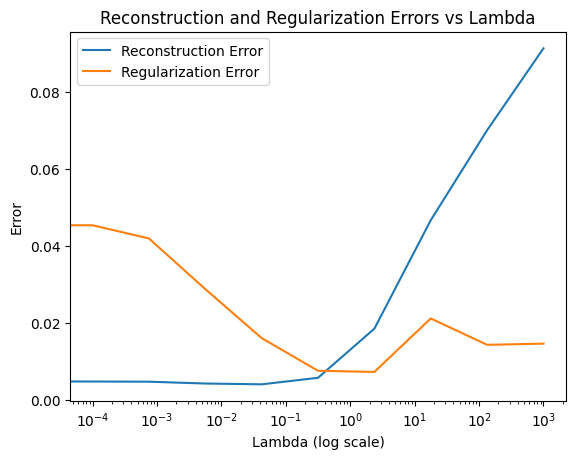

In [12]:
plt.plot(lambda_isos, recon_errors, label='Reconstruction Error')
plt.plot(lambda_isos, regularization_errors, label='Regularization Error')
# plt.ylim(0.005, 0.01)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Error')
plt.title('Reconstruction and Regularization Errors vs Lambda')
plt.legend()
plt.show()

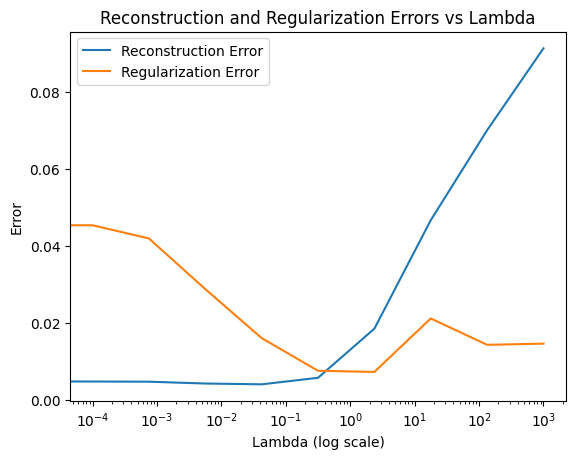

In [14]:
plt.plot(lambda_isos, recon_errors, label='Reconstruction Error')
plt.plot(lambda_isos, regularization_errors, label='Regularization Error')
# plt.ylim(0.0, 0.00002)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Error')
plt.title('Reconstruction and Regularization Errors vs Lambda')
plt.legend()
plt.show()

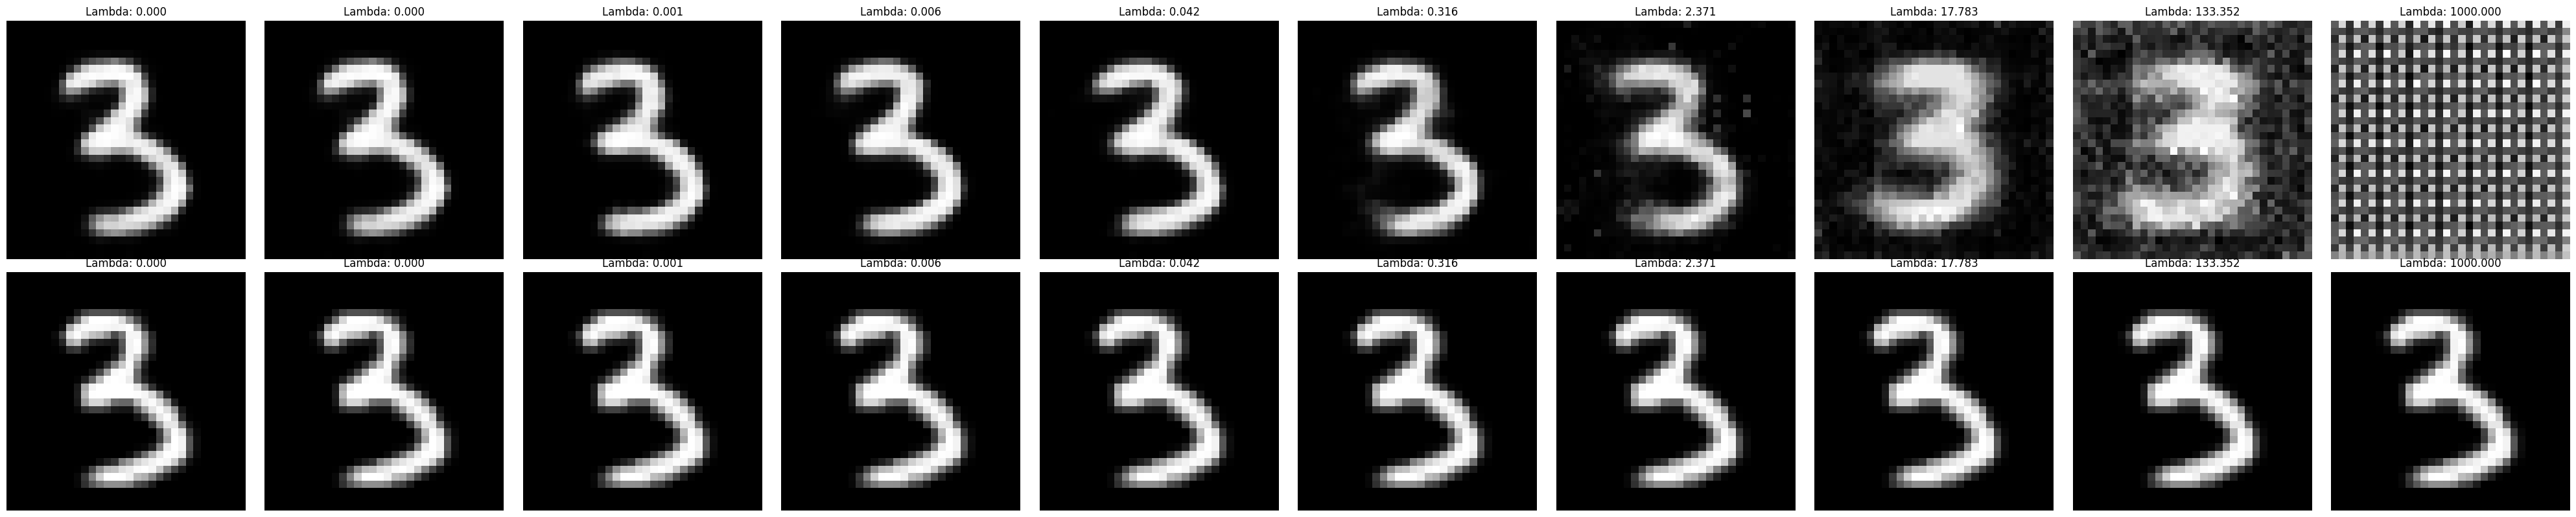

In [15]:
# plot samples and latent space at different lambdas
fig, axs = plt.subplots(2, len(lambda_isos), figsize=(40, 8))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 2)
    model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))

    # model.eval()
    # with torch.no_grad():
    encoded_data = model.encode(val_data[:10])
    reconstruction = model.decode(encoded_data)

    axs[0, i].imshow(reconstruction[2].view(32, 32).cpu().detach().numpy(), cmap='gray')
    axs[0, i].set_title(f'Lambda: {lambda_iso:.3f}')
    axs[0, i].axis('off')

    axs[1, i].imshow(val_data[2].view(32, 32).cpu().detach().numpy(), cmap='gray')
    axs[1, i].set_title(f'Lambda: {lambda_iso:.3f}')
    axs[1, i].axis('off')
plt.tight_layout()

In [16]:
import pandas as pd
from metrics import evaluate_conformality

In [23]:
statses = []
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 2)
    model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    # with torch.no_grad():
    #     encoded_data = model.encode(val_data[:100])
    #     reconstruction = model.decode(encoded_data)

    statses.append(evaluate_conformality(model, val_data[:100]))

df = pd.DataFrame(statses, index=lambda_isos)
# styled_df = df.style.highlight_min(color='green').highlight_max(color='coral')

In [24]:
styled_df = df.style \
    .background_gradient(subset=[
            'reconstruction_error',
            'diagonal_gini',
            'lambda_std',
            'lambda_std_normed',
            'off_diag_mean',
            'off_diag_norm',
            'off_diag_mean_normed',
            'off_diag_norm_normed',
            'jTj_minus_lambdaI_mean',
            'jTj_minus_lambdaI_norm',
            'jTj_minus_lambdaI_mean_normed',
            'jTj_minus_lambdaI_norm_normed',
            'determinant_vs_estimate_std',
            ], cmap='Reds') \
    .background_gradient(subset=[
        'determinant_vs_estimate_mean'
    ], cmap='Greens')\
    .background_gradient(subset=[
        'lambda_mean',
        'latent_std',
        'latent_std_max',
        'latent_std_min',
        'latent_norm',
    ], cmap='Blues')

styled_df

,reconstruction_error,diagonal_gini,lambda_mean,lambda_std,lambda_std_normed,off_diag_mean,off_diag_norm,off_diag_mean_normed,off_diag_norm_normed,jTj_minus_lambdaI_mean,jTj_minus_lambdaI_norm,jTj_minus_lambdaI_mean_normed,jTj_minus_lambdaI_norm_normed,determinant_vs_estimate_mean,determinant_vs_estimate_std,latent_std,latent_std_max,latent_std_min,latent_norm
0.000000,0.004446,0.218609,0.027840,0.004513,0.162112,0.004466,0.185518,0.160667,6.671677,0.004737,0.195361,0.170411,7.024144,0.000000,0.000000,9.724753,13.573597,6.261742,1296.531738
0.000100,0.004446,0.218609,0.027840,0.004513,0.162112,0.004466,0.185518,0.160667,6.671677,0.004737,0.195361,0.170411,7.024145,0.000000,0.000000,9.724753,13.573597,6.261742,1296.531738
0.000750,0.004798,0.223840,0.027541,0.004473,0.162405,0.004302,0.178517,0.156589,6.498193,0.004569,0.189551,0.166267,6.896603,0.000000,0.000000,8.539570,14.002860,5.642223,1118.057495
0.005623,0.004313,0.154614,0.023898,0.004368,0.182765,0.003285,0.135174,0.138080,5.678205,0.003446,0.139961,0.144841,5.878523,0.000000,0.000000,10.932894,15.770899,6.852870,1750.815063
0.042170,0.003968,0.102827,0.004475,0.000690,0.154164,0.000438,0.017897,0.099193,4.051964,0.000458,0.018452,0.103663,4.178424,0.000000,0.000000,26.429869,39.432610,10.539846,4144.915527
0.316228,0.005781,0.071044,0.000514,0.000053,0.103288,0.000036,0.001454,0.069708,2.846752,0.000037,0.001497,0.072790,2.931926,0.000000,0.000000,63.186531,85.615555,30.682470,6500.526855
2.371374,0.012205,0.043078,0.000568,0.000041,0.072204,0.000024,0.000960,0.041421,1.689140,0.000025,0.000990,0.043304,1.741592,0.000000,0.000000,45.223080,62.557270,23.173250,5020.108398
17.782794,0.045745,0.127533,0.000190,0.000006,0.029727,0.000024,0.000986,0.128221,5.178659,0.000025,0.001015,0.133601,5.329860,0.000000,0.000000,0.502686,1.482463,0.056403,2092.581543
133.352143,0.054741,0.067387,0.000501,0.000006,0.011679,0.000037,0.001474,0.073260,2.939887,0.000038,0.001512,0.076079,3.016224,0.000000,0.000000,0.172474,0.429413,0.005046,1470.261719
1000.000000,0.084031,0.068950,0.000468,0.000000,0.000003,0.000044,0.001765,0.094480,3.768558,0.000046,0.001793,0.097433,3.827887,0.000000,0.000000,0.000412,0.000851,0.000109,7.131016


FileNotFoundError: [Errno 2] No such file or directory: 'models/conformal_autoencoder_mnist_vec/lambda_0.000_model_1.pth'

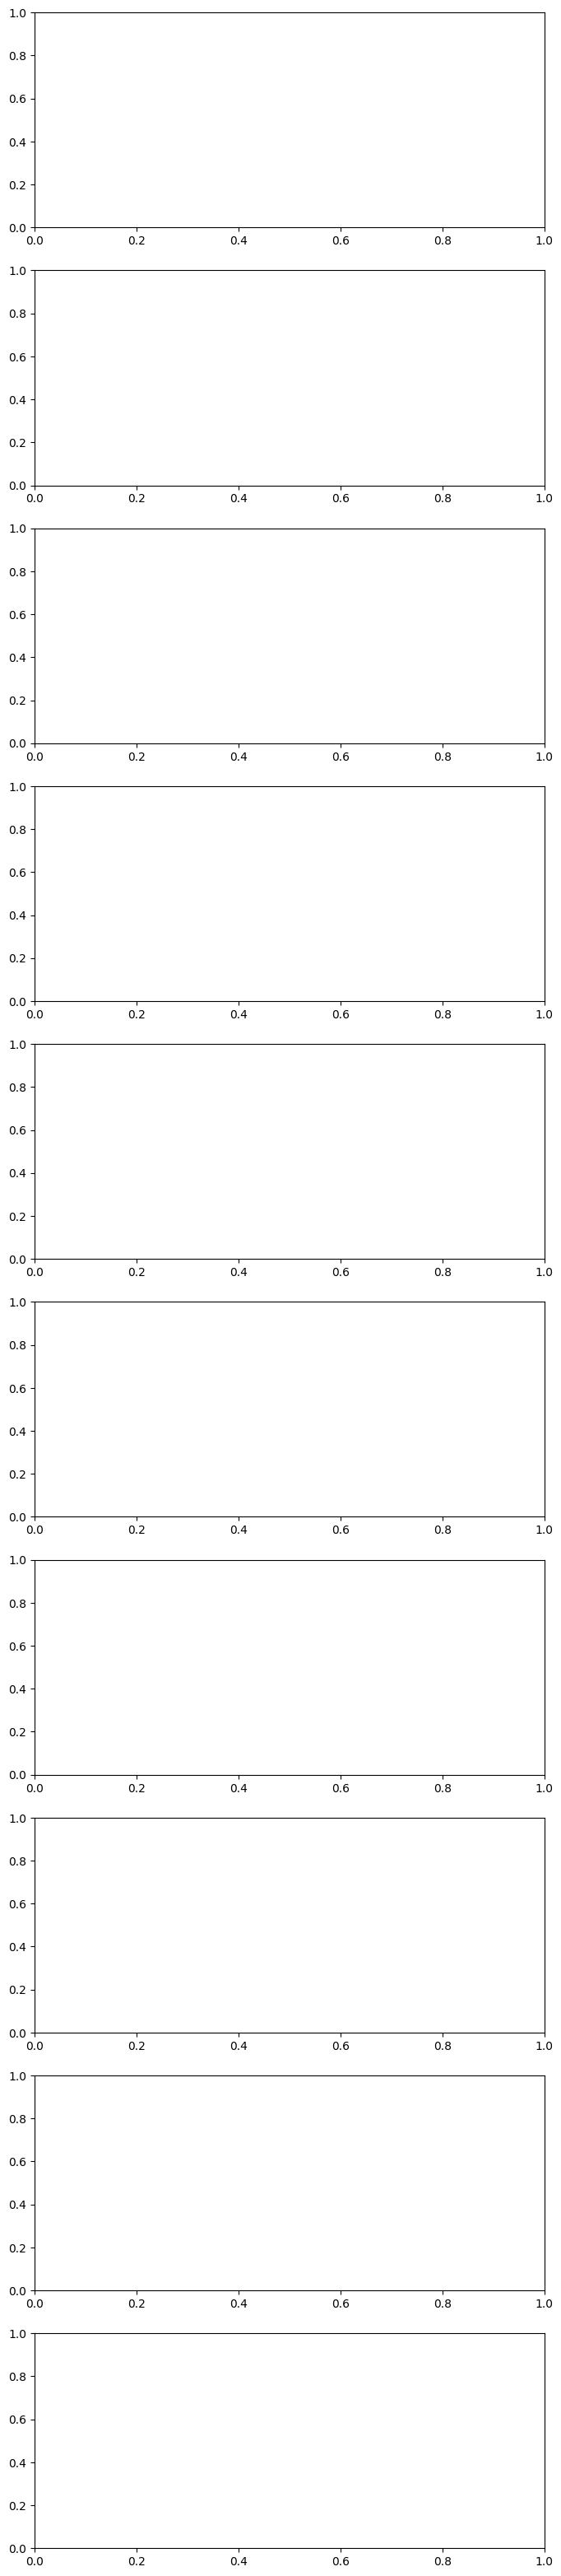

In [25]:
fig, axs = plt.subplots(len(lambda_isos), 1, figsize=(8, 40))
for j, lambda_iso in enumerate(lambda_isos):
    model_path = f"models/conformal_autoencoder_mnist_vec/lambda_{lambda_iso:.3f}_model_1.pth"
    model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))

    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data[:200])
        reconstruction = model.decode(encoded_data)

    JtJs = torch.zeros((latent_dim, latent_dim)).to(device)
    for i, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension

        J = torch.autograd.functional.jacobian(model.decoder, z)[0,0,:,:,0,:]
        J = J.reshape(-1, 32)  # Reshape to (latent_dim, flattened_output_dim)
        JtJ = J.transpose(0, 1) @ J
        JtJs += JtJ

    JtJs /= encoded_data.shape[0]  # Average over all points

    p = axs[j].imshow(JtJs.cpu().detach().numpy(), cmap='hot')
    axs[j].set_title(f'Lambda: {lambda_iso:.3f}')
    axs[j].axis('off')
    plt.colorbar(p)
plt.tight_layout()

In [ ]:

conformal_autoencoder.eval()
with torch.no_grad():
    encoded_data = conformal_autoencoder.encode(val_data[:1000])
    reconstruction = conformal_autoencoder.decode(encoded_data)

JtJs = torch.zeros((latent_dim, latent_dim)).to(device)
for i, z in enumerate(encoded_data):
    z = z.unsqueeze(0)  # Add batch dimension

    J = torch.autograd.functional.jacobian(conformal_autoencoder.decoder, z)[0,0,:,:,0,:]
    J = J.reshape(-1, 32)  # Reshape to (latent_dim, flattened_output_dim)
    JtJ = J.transpose(0, 1) @ J
    JtJs += JtJ

JtJs /= encoded_data.shape[0]  # Average over all points

plt.imshow(JtJs.cpu().numpy(), cmap='hot')
plt.colorbar()
plt.title('Average J^T J')
plt.axis('off')
plt.show()

In [ ]:
model_path = f"models/conformal_autoencoder_mnist_vec/lambda_{lambda_isos[-1]:.3f}_model_1.pth"
model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_isos[-1]).to(device)
model.load_state_dict(torch.load(model_path))

model.eval()
with torch.no_grad():
    encoded_data = model.encode(val_data[:2])
    reconstruction = model.decode(encoded_data)


    for i, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = model.decoder(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(model.decoder, z)[0,:,0,:]
        JtJ = J.transpose(0, 1) @ J
        print(JtJ.size())
        print(encoded_data.size())

    #     eye = torch.eye(JtJ.size(0), device=device)
    #     off_diag_mask = 1.0 - eye
    #     off_diag_elements = JtJ[off_diag_mask.bool()]
    #     loss_matrix = off_diag_elements ** 2

    #     losses.append(loss_matrix.mean().item())
    
    # return np.mean(losses).item()

torch.Size([28, 28, 1, 64, 1, 1])
torch.Size([2, 64, 1, 1])
torch.Size([28, 28, 1, 64, 1, 1])
torch.Size([2, 64, 1, 1])


In [49]:
print(JtJ[:,:,0,0,0,0])

tensor([[ 3.0352e-18,  5.2367e-17,  2.9216e-18,  1.0972e-19,  5.9667e-21,
          9.4161e-21,  1.8404e-21,  2.0862e-22,  4.2756e-22,  2.7949e-20,
          9.5245e-20,  7.9838e-20,  2.1337e-22,  1.2245e-24,  4.7852e-26,
          3.2307e-27, -4.6334e-24, -4.1562e-23, -4.6581e-21, -5.7762e-21,
          9.4572e-24,  4.5367e-25,  2.4468e-23,  3.7554e-24,  8.7466e-24,
          2.5008e-23,  3.5209e-21,  2.7895e-17],
        [ 5.2367e-17,  9.0350e-16,  5.0408e-17,  1.8931e-18,  1.0295e-19,
          1.6246e-19,  3.1753e-20,  3.5994e-21,  7.3769e-21,  4.8221e-19,
          1.6433e-18,  1.3775e-18,  3.6813e-21,  2.1127e-23,  8.2561e-25,
          5.5740e-26, -7.9941e-23, -7.1709e-22, -8.0368e-20, -9.9658e-20,
          1.6317e-22,  7.8273e-24,  4.2215e-22,  6.4794e-23,  1.5091e-22,
          4.3147e-22,  6.0748e-20,  4.8128e-16],
        [ 2.9216e-18,  5.0408e-17,  2.8124e-18,  1.0562e-19,  5.7435e-21,
          9.0639e-21,  1.7716e-21,  2.0082e-22,  4.1157e-22,  2.6903e-20,
          9.16

In [35]:
def diagonality_loss(func, z):
    device = z.device
    losses = []
    for i, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = func(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(func, z)[0,:,0,:]
        JtJ = J.transpose(0, 1) @ J

        eye = torch.eye(JtJ.size(0), device=device)
        off_diag_mask = 1.0 - eye
        off_diag_elements = JtJ[off_diag_mask.bool()]
        loss_matrix = off_diag_elements ** 2

        losses.append(loss_matrix.mean().item())
    
    return np.mean(losses).item()

In [13]:
# measure isometry, scaled isometry, conformity, diagonality, (angle preservation, kl)
from metrics import isometry_loss, scaled_isometry_loss, conformality_loss

for i, lambda_iso in enumerate(lambda_isos):
    print(f"Evaluating model with lambda_iso={lambda_iso:.3f}")
    model_path = f"models/conformal_autoencoder_mnist_vec/lambda_{lambda_iso:.3f}_model_1.pth"
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))

    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data[:10])
        reconstruction = model.decode(encoded_data)

    isometry = isometry_loss(model.decoder, encoded_data, create_graph=False, augment=False)
    scaled_isometry = scaled_isometry_loss(model.decoder, encoded_data, create_graph=False, augment=False)
    # conformality = conformality_loss(model.decoder, encoded_data)
    diagonality = diagonality_loss(model.decoder, encoded_data)
    print(f"Isometry Loss: {isometry.item()}")
    print(f"Scaled Isometry Loss: {scaled_isometry.item()}")
    # print(f"Conformality Loss: {conformality.item()}")
    print(f"Diagonality Loss: {diagonality}")
    print("-" * 50)

Evaluating model with lambda_iso=0.001


RuntimeError: Error(s) in loading state_dict for ConformalAutoencoder:
	size mismatch for decoder.fc.0.weight: copying a param with shape torch.Size([64, 32]) from checkpoint, the shape in current model is torch.Size([64, 1]).
	size mismatch for decoder.deconv.4.weight: copying a param with shape torch.Size([8, 1, 3, 3]) from checkpoint, the shape in current model is torch.Size([8, 32, 3, 3]).
	size mismatch for decoder.deconv.4.bias: copying a param with shape torch.Size([1]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for model.1.fc.0.weight: copying a param with shape torch.Size([64, 32]) from checkpoint, the shape in current model is torch.Size([64, 1]).
	size mismatch for model.1.deconv.4.weight: copying a param with shape torch.Size([8, 1, 3, 3]) from checkpoint, the shape in current model is torch.Size([8, 32, 3, 3]).
	size mismatch for model.1.deconv.4.bias: copying a param with shape torch.Size([1]) from checkpoint, the shape in current mode